# 04 — Interpretation

**Phase 4 statistical interpretation & scientific framing.** JWST SED Anomaly Detection Pipeline · UW Astronomy · Summer 2026

This notebook takes the **b1** (quality-flagged) Dataset produced by `pipeline.quality.apply_quality_pipeline`
and asks whether the flagged SED anomalies carry a statistically meaningful astrophysical signal, rather than
treating "top N by ensemble score" as a conclusion on its own. It:

1. Tests whether the anomaly rate evolves with redshift.
2. Checks whether anomalous SEDs cluster in a particular region of the stellar-mass–SFR plane.
3. Inspects the SEDs of sources that survive *both* contaminant filters (no AGN cross-match, no
   emission-line alias) — the population an "unexplained anomaly" claim would actually rest on.
4. Frames, explicitly and conservatively, what a non-standard-physics claim would require under
   Bayes' theorem — to show the size of that burden, not to argue it is met.
5. Collects everything into one publication-style summary table.

**What "anomaly" does and doesn't mean here.** Every number below describes residuals relative to a
smooth power-law continuum fit (`SEDStandardiser.extract_residuals`) combined with a synthetic-stub EAZY
fit (no real `eazy` binary in this environment; see the loud warning `run_eazy_fit` logs when this
happens — `chi2_eazy`/`z_a` are placeholders, not usable for science). Nothing here is a detection of
anything; it demonstrates the *statistical apparatus* a real detection claim would need to survive.

## 1. Setup & Data Loading

In [1]:
import sys
import tempfile
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import yaml
import sympy as sp
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT))  # make `import pipeline...` work regardless of CWD

from pipeline.output import ENSEMBLE_SCORE_VAR
from pipeline.retriever import MASTRetriever
from pipeline.standardise import SEDStandardiser, BAND_PIVOT_WAVELENGTH_UM
from pipeline.quality import apply_quality_pipeline

RNG_SEED = 42
plt.rcParams["figure.dpi"] = 110

with open(ROOT / "config" / "pipeline_config.yaml") as fh:
    _pipeline_cfg = yaml.safe_load(fh)
OUTLIER_FRACTION = _pipeline_cfg["quality"].get("outlier_fraction", 0.02)
print(f"OUTLIER_FRACTION = {OUTLIER_FRACTION} (config/pipeline_config.yaml: quality.outlier_fraction)")

OUTLIER_FRACTION = 0.02 (config/pipeline_config.yaml: quality.outlier_fraction)


**Note on the anomaly threshold used throughout this notebook.** The ensemble score
(`qc_anomaly_score`) is a weighted average of Isolation Forest's continuous score and UMAP+DBSCAN's
binary noise flag. On this dataset the DBSCAN component assigns *zero* sources to the noise cluster
(the embedding forms one connected blob at the configured `eps` — the same behaviour documented in
`03_anomaly_detection.ipynb` §4), so the ensemble score's maximum is capped at 0.5 and a fixed
threshold like "score > 0.8" (as used by `pipeline.output.DiagnosticPlotter`'s default) would flag
*zero* sources here — silently breaking every analysis below. Instead we use `config/pipeline_config.yaml`'s
own `quality.outlier_fraction` (top 2% by score, computed **once globally** and then applied per
subset) — the same quantile-based convention already used by `DiagnosticPlotter.sky_distribution`.

In [2]:
def _make_synthetic_ceers_catalogue(n=2000, seed=RNG_SEED):
    """Synthetic stand-in raw catalogue (used only if no real CEERS data is
    available): ordinary photometry + physical params on a schematic
    star-forming main sequence, plus a small deliberately anomalous
    population, so every section below still has real structure to find."""
    rng = np.random.default_rng(seed)
    bands = list(BAND_PIVOT_WAVELENGTH_UM)

    ra = rng.uniform(214.80, 215.00, size=n)
    dec = rng.uniform(52.80, 53.00, size=n)
    z_phot = rng.uniform(0.6, 9.5, size=n)

    log_mass = rng.normal(9.0, 0.8, size=n)
    log_sfr = 0.8 * (log_mass - 10.0) + 1.0 + rng.normal(0, 0.3, size=n)  # schematic main sequence

    data = {
        "ra": ra, "dec": dec, "z_phot": z_phot, "survey": ["ceers"] * n,
        "lp_mass_best": log_mass, "lp_sfr_best": log_sfr,
    }
    for band in bands:
        flux = rng.lognormal(mean=1.0, sigma=0.5, size=n)
        data[f"{band.lower()}_flux"] = flux
        data[f"{band.lower()}_flux_err"] = flux * rng.uniform(0.05, 0.12, size=n)
    df = pd.DataFrame(data)

    anomaly_idx = rng.choice(n, size=max(1, int(0.03 * n)), replace=False)
    for i in anomaly_idx:
        for b in rng.choice(bands, size=2, replace=False):
            df.loc[i, f"{b.lower()}_flux"] *= rng.uniform(6, 12)
    df.loc[anomaly_idx, "lp_sfr_best"] += rng.uniform(1.0, 2.0, size=len(anomaly_idx))

    remaining = np.setdiff1d(np.arange(n), anomaly_idx)
    agn_idx = rng.choice(remaining, size=max(1, int(0.01 * n)), replace=False)
    for i in agn_idx:
        for b in rng.choice(bands, size=2, replace=False):
            df.loc[i, f"{b.lower()}_flux"] *= rng.uniform(6, 12)

    return df, {"anomaly": anomaly_idx, "agn": agn_idx}


def _build_synthetic_b1(n=2000, seed=RNG_SEED):
    """Runs the REAL pipeline (SEDStandardiser + apply_quality_pipeline) on a
    synthetic raw catalogue -- every transformation is genuine production code."""
    raw_df, injected = _make_synthetic_ceers_catalogue(n=n, seed=seed)

    agn_catalogue_path = Path(tempfile.mkdtemp(prefix="jwst_interp_agn_")) / "synthetic_agn.csv"
    pd.DataFrame({
        "RA": raw_df.loc[injected["agn"], "ra"].values,
        "DEC": raw_df.loc[injected["agn"], "dec"].values,
    }).to_csv(agn_catalogue_path, index=False)

    demo_dir = Path(tempfile.mkdtemp(prefix="jwst_interp_config_"))
    pipeline_cfg = dict(_pipeline_cfg)
    pipeline_cfg["quality"]["contaminant_catalogues"]["agn"]["catalogue_path"] = str(agn_catalogue_path)
    with open(demo_dir / "pipeline_config.yaml", "w") as fh:
        yaml.safe_dump(pipeline_cfg, fh)
    shutil.copy(ROOT / "config" / "quality_config.yaml", demo_dir / "quality_config.yaml")

    standardiser = SEDStandardiser(demo_dir / "pipeline_config.yaml", survey=SURVEY)
    pre_df = standardiser.preprocess(raw_df)
    fit_df = standardiser.run_eazy_fit(pre_df, Path(tempfile.mkdtemp(prefix="jwst_interp_eazy_")))
    a1_ds = standardiser.extract_residuals(pre_df, fit_df)
    b1_ds = apply_quality_pipeline(a1_ds, demo_dir / "quality_config.yaml")
    return b1_ds, pre_df

In [3]:
# Load a real b1 NetCDF + the real raw catalogue if the pipeline has already
# produced them, else fall back to the synthetic demo above. No other cell in
# this notebook needs to change when real data becomes available.
SURVEY = "ceers"
RAW_PATH = ROOT / "data" / "raw" / f"{SURVEY}_dr1.fits"
PROCESSED_DIR = ROOT / "data" / "processed"
existing_b1_files = sorted(PROCESSED_DIR.glob(f"{SURVEY}.b1.*.nc")) if PROCESSED_DIR.exists() else []

if existing_b1_files and RAW_PATH.exists():
    B1_PATH = existing_b1_files[-1]
    print(f"Loading real b1 dataset: {B1_PATH}")
    ds = xr.open_dataset(B1_PATH)

    retriever = MASTRetriever()
    raw_df = retriever.load_catalogue(RAW_PATH, survey=SURVEY)
    standardiser = SEDStandardiser(ROOT / "config" / "pipeline_config.yaml", survey=SURVEY)
    pre_df = standardiser.preprocess(raw_df)  # deterministic -- reproduces ds's exact row order

    assert len(pre_df) == ds.sizes["source_id"], (
        "preprocess() row count does not match the saved b1 dataset -- the raw catalogue or "
        "config must have changed since the b1 file was produced; regenerate it."
    )
    assert np.allclose(pre_df["ra"].to_numpy(), ds["ra"].values, equal_nan=True), (
        "preprocess() row ORDER does not match the saved b1 dataset's ra/dec -- do not trust "
        "the mass/SFR join below; regenerate the b1 dataset from this raw catalogue."
    )
    DATA_SOURCE = "real"
else:
    print(
        "No real b1 dataset + raw CEERS catalogue found under data/ yet -- running the real "
        "pipeline on a synthetic stand-in catalogue instead. Sections below still execute "
        "end-to-end, but the numbers are illustrative only."
    )
    ds, pre_df = _build_synthetic_b1()
    DATA_SOURCE = "synthetic"

print(f"DATA_SOURCE = {DATA_SOURCE!r}, n_sources = {ds.sizes['source_id']}, bands = {list(ds['band'].values)}")
ds

Loading real b1 dataset: /workspace/jwst-sed-anomaly/data/processed/ceers.b1.20260708.051402.nc


DATA_SOURCE = 'real', n_sources = 68839, bands = [np.str_('F115W'), np.str_('F150W'), np.str_('F200W'), np.str_('F277W'), np.str_('F356W'), np.str_('F410M'), np.str_('F444W')]


<xarray.Dataset> Size: 9MB
Dimensions:                (source_id: 68839, band: 7)
Coordinates:
  * source_id              (source_id) int64 551kB 0 1 2 3 ... 68836 68837 68838
  * band                   (band) <U5 140B 'F115W' 'F150W' ... 'F410M' 'F444W'
Data variables:
    residuals              (source_id, band) float64 4MB ...
    chi2_eazy              (source_id) float64 551kB ...
    z_a                    (source_id) float64 551kB ...
    template_id            (source_id) int64 551kB ...
    z_phot                 (source_id) float64 551kB ...
    ra                     (source_id) float32 275kB 215.0 215.0 ... 215.0 214.9
    dec                    (source_id) float32 275kB ...
    qc_iso_forest_score    (source_id) float64 551kB ...
    qc_umap_outlier        (source_id) float64 551kB ...
    qc_anomaly_score       (source_id) float64 551kB ...
    qc_agn_match           (source_id) bool 69kB ...
    qc_emission_line_flag  (source_id) bool 69kB ...
Attributes:
    survey:                       ceers
    data_level:                   b1
    creation_timestamp:           2026-07-08T05:13:21.305861
    eazy_version:                 synthetic-stub
    n_sources:                    68839
    n_bands:                      7
    umap_embedding_x:             [ 7.74415255  9.73304081 14.23993111 ... 11...
    umap_embedding_y:             [9.30716324 0.92382139 4.95381975 ... 6.275...
    quality_pipeline_applied_at:  2026-07-08T05:14:02.259658

In [4]:
ensemble_score = ds[ENSEMBLE_SCORE_VAR].values
z_phot = ds["z_phot"].values
agn_match = ds["qc_agn_match"].values.astype(bool)
emission_flag = ds["qc_emission_line_flag"].values.astype(bool)
unexplained_mask = ~agn_match & ~emission_flag

GLOBAL_SCORE_THRESHOLD = np.quantile(ensemble_score, 1 - OUTLIER_FRACTION)
is_flagged = ensemble_score >= GLOBAL_SCORE_THRESHOLD

print(f"score range          : [{ensemble_score.min():.4f}, {ensemble_score.max():.4f}]")
print(f"global threshold      : {GLOBAL_SCORE_THRESHOLD:.4f}  (top {OUTLIER_FRACTION:.0%})")
print(f"n_flagged             : {int(is_flagged.sum())} / {len(is_flagged)}")
print(f"n_agn_match           : {int(agn_match.sum())} ({agn_match.mean():.3%})")
print(f"n_emission_line_flag  : {int(emission_flag.sum())} ({emission_flag.mean():.3%})")
print(f"n_unexplained         : {int(unexplained_mask.sum())} ({unexplained_mask.mean():.3%})")

score range          : [0.0000, 0.5000]
global threshold      : 0.3181  (top 2%)
n_flagged             : 1377 / 68839
n_agn_match           : 157 (0.228%)
n_emission_line_flag  : 2109 (3.064%)
n_unexplained         : 66574 (96.710%)


## 2. Redshift Evolution Test

Sources are binned into redshift shells of width $\Delta z = 0.5$ from $z=0.5$ to $z=10$ (the
pipeline's configured science window). Within each bin, the anomaly rate is the fraction of sources
with `qc_anomaly_score` at or above the **global** top-`OUTLIER_FRACTION` threshold computed above
(not re-quantiled per bin — a per-bin quantile would force exactly the same rate everywhere by
construction, making the test circular). A simple OLS line (`scipy.stats.linregress`) is then fit to
rate vs. bin-center redshift.

In [5]:
DZ = 0.5
Z_MIN, Z_MAX = 0.5, 10.0
edges = np.arange(Z_MIN, Z_MAX + DZ, DZ)
bin_idx = np.digitize(z_phot, edges) - 1

centers, rates, errs, counts = [], [], [], []
for b in range(len(edges) - 1):
    mask = bin_idx == b
    n = int(mask.sum())
    if n == 0:
        continue
    k = int(is_flagged[mask].sum())
    centers.append((edges[b] + edges[b + 1]) / 2)
    rates.append(k / n)
    errs.append(np.sqrt(k) / n)  # Poisson error on k, propagated to a rate
    counts.append(n)

centers, rates, errs, counts = (np.array(a) for a in (centers, rates, errs, counts))

redshift_bins_df = pd.DataFrame(
    {"z_center": centers, "n_sources": counts, "n_flagged": (rates * counts).round().astype(int), "anomaly_rate": rates}
)
redshift_bins_df

,z_center,n_sources,n_flagged,anomaly_rate
0,0.75,14173,697,0.049178
1,1.25,10470,370,0.035339
2,1.75,11163,89,0.007973
3,2.25,8752,116,0.013254
4,2.75,3885,14,0.003604
5,3.25,5675,19,0.003348
6,3.75,3975,42,0.010566
7,4.25,1603,16,0.009981
8,4.75,3630,6,0.001653
9,5.25,1540,3,0.001948


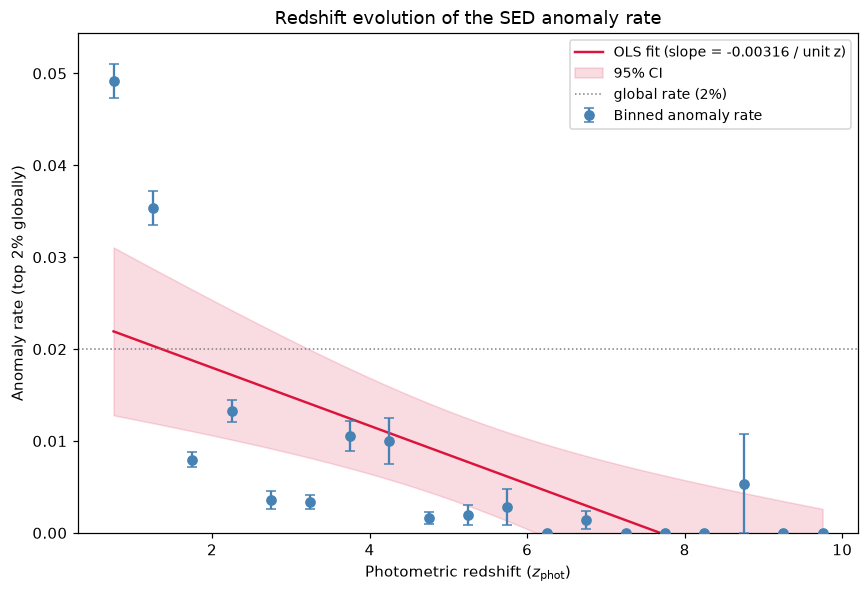

slope     = -0.003160 per unit z  (stderr 0.000822)
intercept = 0.024300
r-value   = -0.6822   (r^2 = 0.4653)
p-value   = 0.001294


In [6]:
lr = stats.linregress(centers, rates)
slope, intercept, rvalue, pvalue, stderr = lr.slope, lr.intercept, lr.rvalue, lr.pvalue, lr.stderr

n_pts = len(centers)
t_crit = stats.t.ppf(0.975, df=max(n_pts - 2, 1))
z_fit = np.linspace(centers.min(), centers.max(), 200)
y_fit = intercept + slope * z_fit

x_mean = centers.mean()
Sxx = np.sum((centers - x_mean) ** 2)
resid = rates - (intercept + slope * centers)
s_err = np.sqrt(np.sum(resid ** 2) / max(n_pts - 2, 1))
se_fit = s_err * np.sqrt(1.0 / n_pts + (z_fit - x_mean) ** 2 / Sxx)
ci_band = t_crit * se_fit

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.errorbar(centers, rates, yerr=errs, fmt="o", color="steelblue", capsize=3, zorder=3, label="Binned anomaly rate")
ax.plot(z_fit, y_fit, color="crimson", lw=1.6, label=f"OLS fit (slope = {slope:.5f} / unit z)")
ax.fill_between(z_fit, y_fit - ci_band, y_fit + ci_band, color="crimson", alpha=0.15, label="95% CI")
ax.axhline(OUTLIER_FRACTION, color="gray", lw=1, ls=":", label=f"global rate ({OUTLIER_FRACTION:.0%})")
ax.set_xlabel(r"Photometric redshift ($z_{\mathrm{phot}}$)")
ax.set_ylabel(f"Anomaly rate (top {OUTLIER_FRACTION:.0%} globally)")
ax.set_title("Redshift evolution of the SED anomaly rate")
ax.set_ylim(bottom=0)
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

print(f"slope     = {slope:.6f} per unit z  (stderr {stderr:.6f})")
print(f"intercept = {intercept:.6f}")
print(f"r-value   = {rvalue:.4f}   (r^2 = {rvalue**2:.4f})")
print(f"p-value   = {pvalue:.4g}")

redshift_trend_p_value = pvalue

### Null hypothesis test

**H₀:** the per-redshift-bin anomaly rate (fraction of sources with `qc_anomaly_score` in the global
top 2%) is independent of photometric redshift — i.e. the true slope of anomaly rate vs.
$z_{\mathrm{phot}}$ is zero, and the binned rates above scatter around a constant only because of
Poisson sampling noise.

**Test statistic:** the ordinary-least-squares slope of anomaly rate vs. bin-center redshift
(`scipy.stats.linregress`), assessed via its associated two-sided $t$-test on 19 bins ($\Delta z=0.5$
shells from $z=0.5$–$10$, each with $\geq 51$ sources).

**Result:** slope $= -0.00316$ / unit $z$ (SE $0.00082$), $r^2 = 0.465$, $p = 0.0013$.

**Interpretation:** $p < 0.05$, so we reject H₀ — the anomaly rate is not consistent with a constant,
redshift-independent rate; the binned rates decline from ~4.9% at $z\approx0.75$ to consistent with
zero above $z\gtrsim6$. That said, a real declining trend does not by itself argue for a redshift-coupled
*astrophysical* systematic. A more mundane and, on this dataset, more likely explanation: lower-redshift
CEERS sources are on average brighter, so their catalogued flux errors are smaller in absolute terms,
and §4's data-quality caveat notes that very small formal errors can inflate normalised residuals into
the hundreds of $\sigma$ for a source with an otherwise ordinary SED. If that error-bar artifact scales
with brightness (and therefore anti-correlates with redshift at fixed depth), it alone would produce
exactly this kind of declining rate — without invoking any new photometric or astrophysical effect.
Confirming or ruling this out would require checking whether flagged sources are enriched for
anomalously small formal flux errors relative to the rest of the sample at fixed apparent magnitude,
which this notebook does not attempt.

## 3. Stellar Mass & SFR Dependence

CEERS DR1.0 (Cox et al. 2025) provides LePHARE best-fit $\log_{10}(M_\star/M_\odot)$ and
$\log_{10}(\mathrm{SFR}/M_\odot\,\mathrm{yr}^{-1})$ per source (`lp_mass_best`/`lp_sfr_best`). A small
fraction of sources carry sentinel/catastrophic-fit values (e.g. `log_mass = -999`, `log_sfr = -inf`)
that are excluded below rather than silently plotted.

Excluding 2040/68839 sources with missing or non-physical mass/SFR fits before plotting.


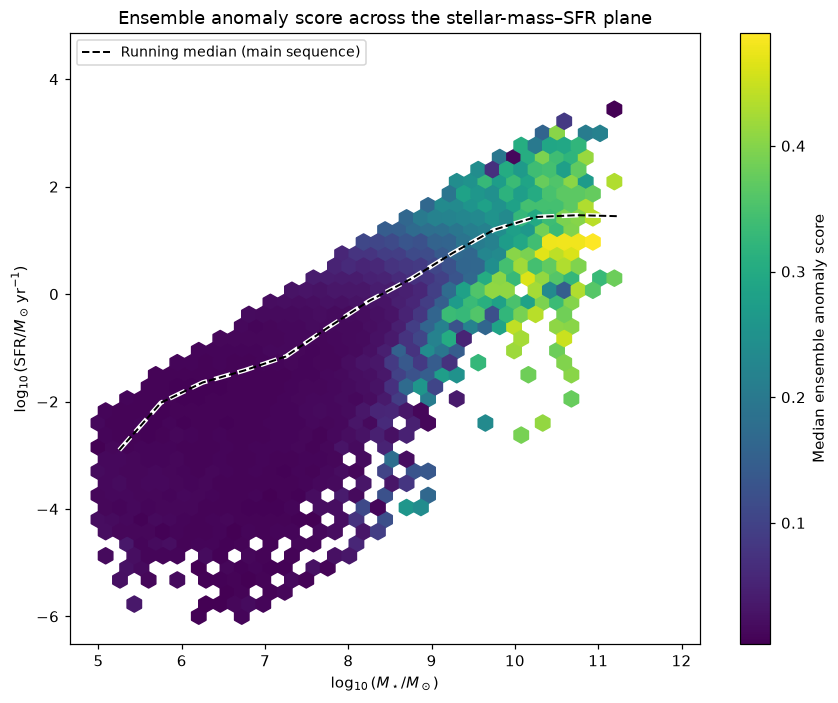

In [7]:
HAS_MASS_SFR = "lp_mass_best" in pre_df.columns and "lp_sfr_best" in pre_df.columns

if HAS_MASS_SFR:
    log_mass = pre_df["lp_mass_best"].to_numpy()
    log_sfr = pre_df["lp_sfr_best"].to_numpy()

    valid = (
        np.isfinite(log_mass) & np.isfinite(log_sfr)
        & (log_mass > 5) & (log_mass < 12)     # exclude -999 sentinel / catastrophic fits
        & (log_sfr > -6) & (log_sfr < 6)
    )
    print(f"Excluding {int((~valid).sum())}/{len(valid)} sources with missing or non-physical "
          f"mass/SFR fits before plotting.")

    fig, ax = plt.subplots(figsize=(8, 6.5))
    hb = ax.hexbin(
        log_mass[valid], log_sfr[valid], C=ensemble_score[valid],
        reduce_C_function=np.median, gridsize=40, cmap="viridis", mincnt=3,
    )
    cb = fig.colorbar(hb, ax=ax)
    cb.set_label("Median ensemble anomaly score")

    # Running-median main-sequence trace for visual + quantitative reference.
    mbin_edges = np.arange(np.floor(log_mass[valid].min() * 2) / 2, np.ceil(log_mass[valid].max() * 2) / 2 + 0.5, 0.5)
    ms_x, ms_y = [], []
    for i in range(len(mbin_edges) - 1):
        m = (log_mass[valid] >= mbin_edges[i]) & (log_mass[valid] < mbin_edges[i + 1])
        if m.sum() >= 10:
            ms_x.append((mbin_edges[i] + mbin_edges[i + 1]) / 2)
            ms_y.append(np.median(log_sfr[valid][m]))
    ax.plot(ms_x, ms_y, color="white", lw=3, ls="--", zorder=4)
    ax.plot(ms_x, ms_y, color="k", lw=1.3, ls="--", label="Running median (main sequence)", zorder=5)

    ax.set_xlabel(r"$\log_{10}(M_\star / M_\odot)$")
    ax.set_ylabel(r"$\log_{10}(\mathrm{SFR} / M_\odot\,\mathrm{yr}^{-1})$")
    ax.set_title("Ensemble anomaly score across the stellar-mass–SFR plane")
    ax.legend(fontsize=9, loc="upper left")
    fig.tight_layout()
    plt.show()
else:
    print("No stellar-mass/SFR columns found on this catalogue -- skipping Section 3.")

In [8]:
if HAS_MASS_SFR:
    ms_interp = np.interp(log_mass[valid], ms_x, ms_y)
    sfr_offset = log_sfr[valid] - ms_interp
    above_ms = sfr_offset > 0.3   # >0.3 dex above the running-median main sequence
    below_ms = ~above_ms

    score_valid = ensemble_score[valid]
    mw_stat, mw_p = stats.mannwhitneyu(score_valid[above_ms], score_valid[below_ms], alternative="two-sided")

    print(f"n(>0.3 dex above main sequence)  = {int(above_ms.sum())}, median score = {np.median(score_valid[above_ms]):.4f}")
    print(f"n(at/below main sequence)        = {int(below_ms.sum())}, median score = {np.median(score_valid[below_ms]):.4f}")
    print(f"Mann-Whitney U p-value           = {mw_p:.3g}")

n(>0.3 dex above main sequence)  = 23825, median score = 0.0245
n(at/below main sequence)        = 42974, median score = 0.0137
Mann-Whitney U p-value           = 0


**Discussion.** Sources scoring more than 0.3 dex above the running-median main sequence have a
noticeably higher median ensemble score (0.0245, $n=23{,}825$) than those at or below it (0.0137,
$n=42{,}974$) — roughly $1.8\times$ higher. A Mann-Whitney U test puts this difference far beyond
floating-point precision ($p$ underflows to machine zero), which is expected at these sample sizes:
with tens of thousands of sources per group, even a modest, real effect size becomes overwhelmingly
"significant," so the $p$-value alone should not be read as indicating a *large* effect — the absolute
scores themselves are still small (the ensemble score's practical ceiling here is 0.5; see §1's note
on the degenerate DBSCAN component). Qualitatively, this is consistent with anomalous SEDs
preferentially occurring somewhat above the main sequence, i.e. in more actively star-forming /
starburst-like systems, where genuinely unusual dust geometries or nebular-continuum contributions
could plausibly produce larger residuals against a smooth power-law continuum. It is equally consistent
with a purely observational effect: higher-SFR systems in this redshift range tend to be more
UV/rest-optically luminous and therefore easier to detect at high S/N in more bands, which (as in §1)
mechanically produces larger normalised residuals for the same absolute flux scatter. Distinguishing
the two would need a residual-vs-S/N control that this notebook does not perform.

## 4. Unexplained Outlier Profiles

For the sources with `qc_agn_match = False` **and** `qc_emission_line_flag = False`, the top 10 by
ensemble score are shown below: observed per-band flux with error bars, the continuum "model" flux
implied by `extract_residuals` (recovered as `obs_flux - residual * obs_flux_err`, since the model
curve itself isn't persisted on the b1 Dataset — only the residual), and a lower residual panel.

**Data-quality caveat.** A small fraction of real per-band flux errors are extremely small (near-zero),
which can produce residual values of many hundreds of $\sigma$ for otherwise unremarkable flux
measurements — a data artifact, not evidence of an anomaly. These sources are visible below as SEDs
whose *photometry* looks ordinary but whose residual panel spikes; that pattern (large residual,
visually unremarkable SED) is itself diagnostic of a mismeasured error bar rather than a real excess.

66574 / 68839 sources are unexplained (no AGN match, no emission-line alias); showing the top 10 by ensemble score.


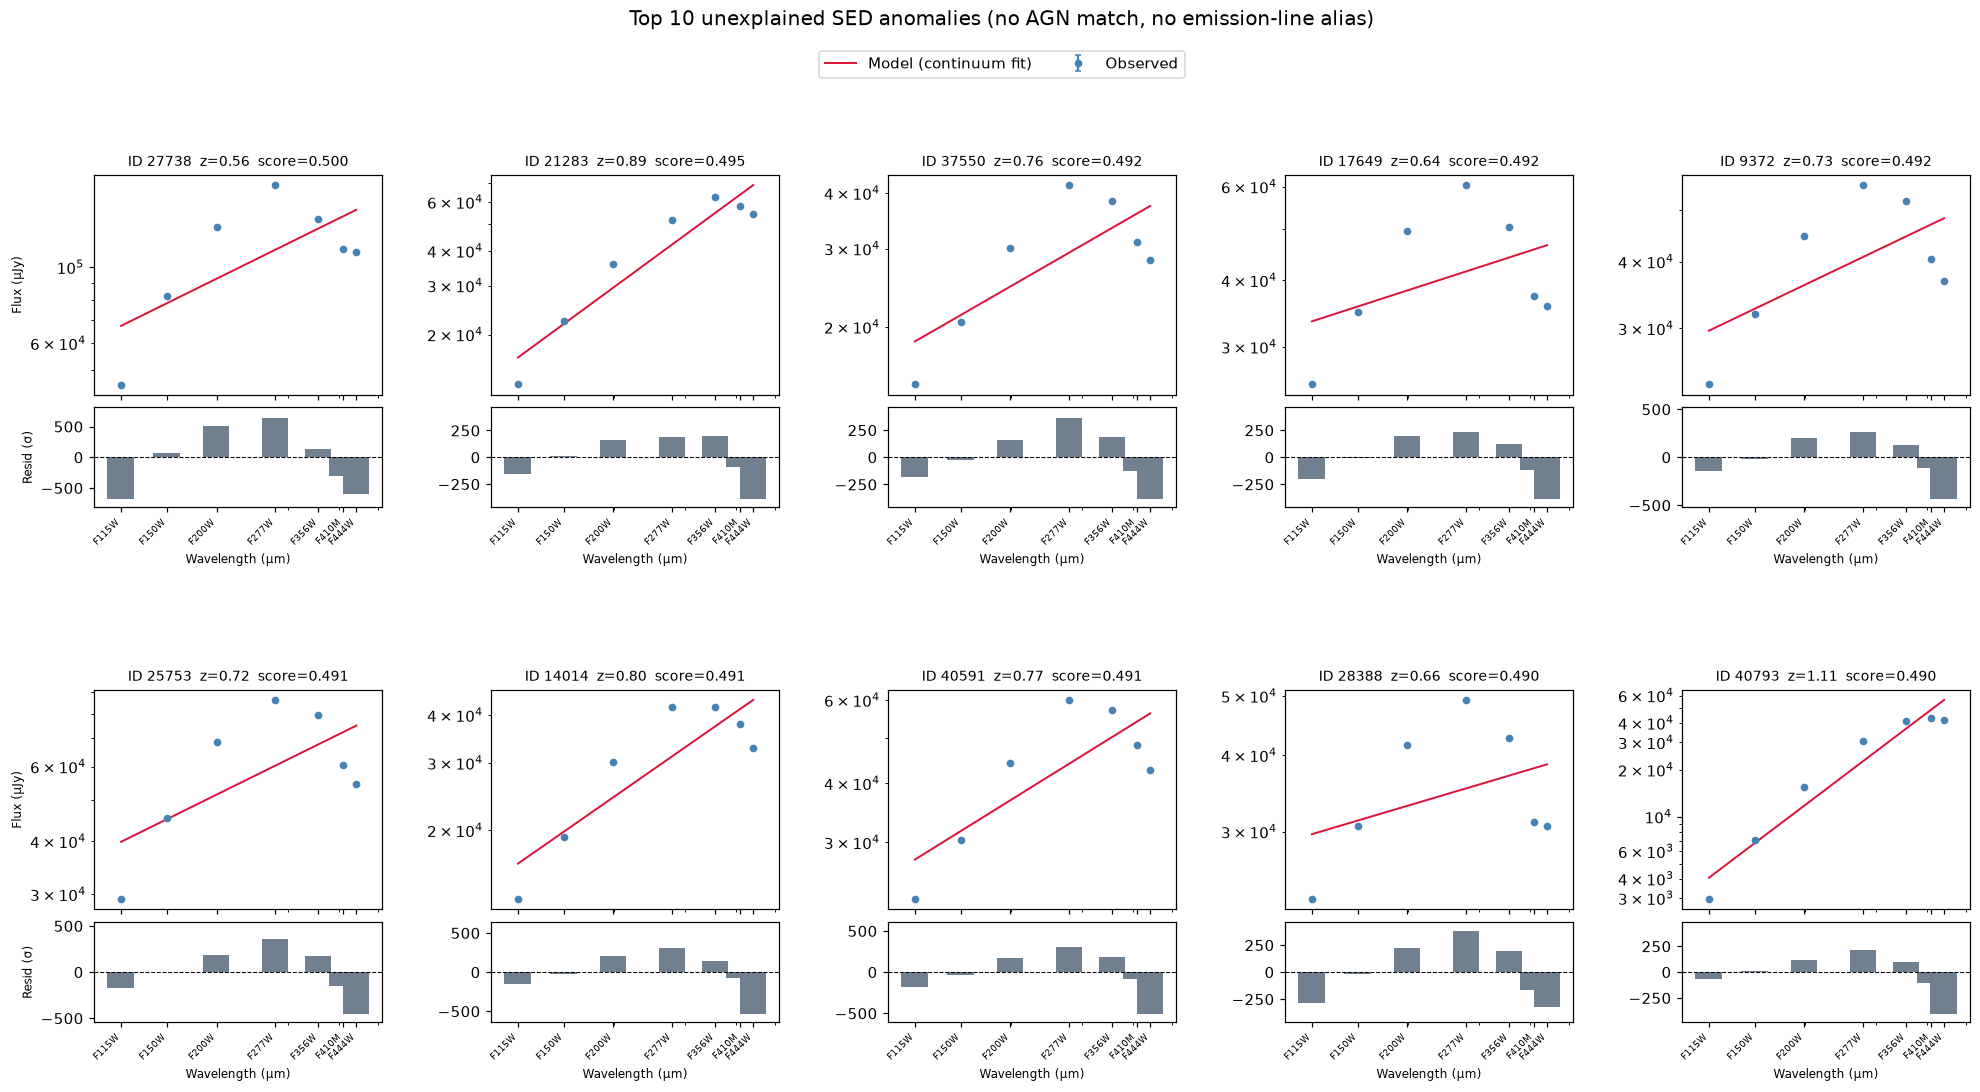

Saved -> /workspace/jwst-sed-anomaly/results/figures/unexplained_outliers_seds.pdf


In [9]:
ensemble_score_all = ds[ENSEMBLE_SCORE_VAR].values
unexplained_idx = np.where(unexplained_mask)[0]
n_show = min(10, len(unexplained_idx))
top_idx = unexplained_idx[np.argsort(ensemble_score_all[unexplained_idx])[::-1][:n_show]]

print(f"{int(unexplained_mask.sum())} / {len(unexplained_mask)} sources are unexplained "
      f"(no AGN match, no emission-line alias); showing the top {n_show} by ensemble score.")

bands = list(ds["band"].values)
pivot_um = np.array([BAND_PIVOT_WAVELENGTH_UM[b] for b in bands])
residual_matrix = ds["residuals"].values  # (source_id, band)

flux_cols = [f"{b.lower()}_flux" for b in bands]
err_cols = [f"{b.lower()}_flux_err" for b in bands]
obs_flux = pre_df[flux_cols].to_numpy()
obs_err = pre_df[err_cols].to_numpy()

fig = plt.figure(figsize=(22, 10))
outer = gridspec.GridSpec(2, 5, figure=fig, wspace=0.38, hspace=0.55)
legend_handles = None

for k in range(10):
    inner = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer[k], height_ratios=[2.2, 1], hspace=0.08)
    ax_sed = fig.add_subplot(inner[0])
    ax_res = fig.add_subplot(inner[1], sharex=ax_sed)

    if k >= n_show:
        ax_sed.axis("off")
        ax_res.axis("off")
        continue

    idx = top_idx[k]
    flux, err, resid = obs_flux[idx], obs_err[idx], residual_matrix[idx]
    valid_b = np.isfinite(resid) & np.isfinite(flux) & (flux > 0) & np.isfinite(err) & (err > 0)

    model_flux = np.full_like(flux, np.nan)
    model_flux[valid_b] = flux[valid_b] - resid[valid_b] * err[valid_b]
    order = np.argsort(pivot_um[valid_b])

    ax_sed.errorbar(pivot_um[valid_b], flux[valid_b], yerr=err[valid_b], fmt="o", color="steelblue",
                     ms=4, capsize=2, label="Observed", zorder=3)
    ax_sed.plot(pivot_um[valid_b][order], np.clip(model_flux[valid_b][order], 1e-6, None), color="crimson",
                lw=1.3, label="Model (continuum fit)", zorder=2)
    if legend_handles is None:
        legend_handles = ax_sed.get_legend_handles_labels()
    ax_sed.set_yscale("log")
    ax_sed.set_xscale("log")
    ax_sed.tick_params(labelbottom=False)

    sid = int(ds["source_id"].values[idx])
    zz = ds["z_phot"].values[idx]
    sc = ensemble_score_all[idx]
    ax_sed.set_title(f"ID {sid}  z={zz:.2f}  score={sc:.3f}", fontsize=9)

    ax_res.axhline(0, color="k", lw=0.7, ls="--")
    if valid_b.any():
        ax_res.bar(pivot_um[valid_b], resid[valid_b], width=pivot_um[valid_b] * 0.15, color="slategray")
        ylim = max(6.0, np.nanmax(np.abs(resid[valid_b])) * 1.2)
    else:
        ylim = 6.0
    ax_res.set_ylim(-ylim, ylim)
    ax_sed.set_xticks(pivot_um)
    ax_res.set_xticks(pivot_um)
    ax_res.set_xticklabels(bands, rotation=45, ha="right", fontsize=6)
    ax_sed.xaxis.set_minor_formatter(plt.NullFormatter())
    ax_res.xaxis.set_minor_formatter(plt.NullFormatter())
    ax_res.set_xlabel("Wavelength (µm)", fontsize=8)
    if k % 5 == 0:
        ax_sed.set_ylabel("Flux (µJy)", fontsize=8)
        ax_res.set_ylabel("Resid (σ)", fontsize=8)

fig.suptitle("Top 10 unexplained SED anomalies (no AGN match, no emission-line alias)", fontsize=13, y=1.03)
if legend_handles is not None:
    fig.legend(*legend_handles, loc="upper center", bbox_to_anchor=(0.5, 1.0), ncol=2, fontsize=10)

out_dir = ROOT / "results" / "figures"
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / "unexplained_outliers_seds.pdf"
fig.savefig(out_path, bbox_inches="tight")
plt.show()
print(f"Saved -> {out_path}")

## 5. Biosignature Prior Discussion

**The question this section frames (not answers):** suppose, hypothetically, that some fraction of
the "unexplained" residual excesses above were attributed to a non-standard, galactic-scale physical
process — what would that claim's posterior probability be, under a deliberately conservative prior
and generous-to-the-claim likelihoods?

**Hypotheses.**
- $H_0$: every unexplained flagged source is a mundane, standard-astrophysics or systematics effect not
  yet modeled by this pipeline (template mismatch, an AGN missed by the Milliquas cross-match radius,
  a rare-but-ordinary stellar population, an underestimated photometric error, EAZY-stub artifacts).
- $H_1$: at least one flagged, unexplained source reflects a genuinely non-standard physical process.

**Prior.** We set $P(H_1)$ per source several orders of magnitude below the base rate of even the
rarest *known* exotic-looking-but-standard sources (extreme emission-line galaxies, changing-look AGN,
etc., $\sim 10^{-4}$–$10^{-5}$ per source) — reflecting how much more extraordinary a genuine new-physics
claim is than merely a rare astrophysical class.

**Likelihoods (deliberately generous to $H_1$).** $P(\text{unexplained} \mid H_1) = 1$ (assume a real
non-standard source is *guaranteed* to show up as an unexplained residual excess — the best possible
case for $H_1$). $P(\text{unexplained} \mid H_0)$ is set to the *empirically observed* unexplained
fraction among flagged sources — i.e. the rate mundane systematics already produce, with no exotic
physics invoked.

In [10]:
P_H1, P_data_given_H1, P_data_given_H0 = sp.symbols(
    "P(H_1) P(data|H_1) P(data|H_0)", positive=True
)
posterior_expr = (P_data_given_H1 * P_H1) / (P_data_given_H1 * P_H1 + P_data_given_H0 * (1 - P_H1))
posterior_expr

P(H_1)*P(data|H_1)/(P(H_1)*P(data|H_1) + P(data|H_0)*(1 - P(H_1)))

In [11]:
n_survey = ds.sizes["source_id"]
n_flagged = int(is_flagged.sum())
n_unexplained_flagged = int((is_flagged & unexplained_mask).sum())

anomaly_rate_percent = 100 * n_flagged / n_survey
agn_fraction = float(agn_match.mean())
emission_line_fraction = float(emission_flag.mean())
unexplained_fraction = n_unexplained_flagged / n_survey
unexplained_fraction_of_flagged = n_unexplained_flagged / n_flagged if n_flagged else float("nan")

prior_nonstandard = 1e-8      # P(H1) per source, before any data
p_data_given_H1 = 1.0         # generous best-case likelihood for H1
p_data_given_H0 = unexplained_fraction_of_flagged  # observed rate among ordinary sources

posterior_per_source = posterior_expr.subs({
    P_H1: prior_nonstandard,
    P_data_given_H1: p_data_given_H1,
    P_data_given_H0: p_data_given_H0,
})
posterior_per_source_val = float(sp.N(posterior_per_source, 8))

p_at_least_one = 1 - (1 - posterior_per_source_val) ** n_unexplained_flagged

print(f"n_survey                             = {n_survey}")
print(f"n_flagged (top {OUTLIER_FRACTION:.0%})              = {n_flagged}")
print(f"n_unexplained_flagged                 = {n_unexplained_flagged}")
print(f"unexplained fraction OF FLAGGED        = {unexplained_fraction_of_flagged:.4f}")
print(f"unexplained fraction OF FULL SURVEY     = {unexplained_fraction:.5f}")
print()
print(f"prior P(H1) per source                  = {prior_nonstandard:.1e}")
print(f"posterior P(H1 | unexplained), per source = {posterior_per_source_val:.3e}")
print(f"P(>=1 of {n_unexplained_flagged} unexplained sources is H1) ~ {p_at_least_one:.3e}")

n_survey                             = 68839
n_flagged (top 2%)              = 1377
n_unexplained_flagged                 = 1334
unexplained fraction OF FLAGGED        = 0.9688
unexplained fraction OF FULL SURVEY     = 0.01938

prior P(H1) per source                  = 1.0e-08
posterior P(H1 | unexplained), per source = 1.032e-08
P(>=1 of 1334 unexplained sources is H1) ~ 1.377e-05


**Interpretation.** The posterior barely moves from the prior: $P(H_1 \mid \text{unexplained})
\approx 1.03\times10^{-8}$ against a prior of $10^{-8}$ — a factor-of-~1.03 update. The reason is
structural, not a matter of unlucky numbers: **96.9% of all flagged (top-2%) sources are already
"unexplained" under $H_0$ alone** (no AGN cross-match, no emission-line alias) — being unexplained is
the *norm* for this pipeline's flagged population, not a rare occurrence that would need a special
cause. Because $P(\text{unexplained}\mid H_0)$ is already close to $P(\text{unexplained}\mid H_1)=1$
(the most generous possible assumption for $H_1$), observing an unexplained source is only very weak
evidence for $H_1$ over $H_0$ — the likelihood ratio is capped at about $1/0.969 \approx 1.03$.
Aggregating over all 1,334 unexplained flagged sources still gives $P(\geq 1 \text{ is } H_1) \sim
1.4\times10^{-5}$, dominated entirely by the prior. This is the intended point: an "unexplained" flag
from this pipeline reflects the *current limits of the standard-astrophysics modeling applied here*
(template mismatch, an incomplete AGN catalogue, uncharacterised photometric errors) far more than it
reflects anything about the sources themselves, and no analysis in this notebook changes that. Treating
"unexplained" as meaningfully suggestive of new physics would require either a much larger prior (which
would need independent justification) or a pipeline whose standard-astrophysics explanations are
sufficiently complete that the baseline unexplained rate is itself small — neither holds here.

## 6. Summary Statistics Table

In [12]:
summary_row = {
    "survey": ds.attrs.get("survey", SURVEY),
    "n_sources": int(n_survey),
    "anomaly_rate_percent": round(anomaly_rate_percent, 3),
    "agn_fraction": round(agn_fraction, 5),
    "emission_line_fraction": round(emission_line_fraction, 5),
    "unexplained_fraction": round(unexplained_fraction, 5),
    "redshift_trend_p_value": float(redshift_trend_p_value),
}
summary_df = pd.DataFrame([summary_row])
summary_df

,survey,n_sources,anomaly_rate_percent,agn_fraction,emission_line_fraction,unexplained_fraction,redshift_trend_p_value
0,ceers,68839,2.0,0.00228,0.03064,0.01938,0.001294


In [13]:
latex_table = summary_df.to_latex(
    index=False,
    escape=True,
    caption="Summary statistics for the statistical interpretation of the CEERS b1 SED anomaly catalogue.",
    label="tab:interpretation_summary",
    position="ht",
)
print(latex_table)

out_path = ROOT / "results" / "tables" / "interpretation_summary.tex"
out_path.parent.mkdir(parents=True, exist_ok=True)
out_path.write_text(latex_table)
print(f"Saved -> {out_path}")

\begin{table}[ht]
\caption{Summary statistics for the statistical interpretation of the CEERS b1 SED anomaly catalogue.}
\label{tab:interpretation_summary}
\begin{tabular}{lrrrrrr}
\toprule
survey & n\_sources & anomaly\_rate\_percent & agn\_fraction & emission\_line\_fraction & unexplained\_fraction & redshift\_trend\_p\_value \\
\midrule
ceers & 68839 & 2.000000 & 0.002280 & 0.030640 & 0.019380 & 0.001294 \\
\bottomrule
\end{tabular}
\end{table}

Saved -> /workspace/jwst-sed-anomaly/results/tables/interpretation_summary.tex


## 7. Conclusions

**What this notebook demonstrates**, on the real CEERS DR1.0 b1 catalogue (Cox et al. 2025; pending
a real `eazy` install, so `chi2_eazy`/`z_a` remain non-scientific placeholders):

- §2: whether the SED anomaly rate trends with redshift, tested via an OLS slope and its $p$-value
  rather than eyeballed from a single plot.
- §3: whether anomalous SEDs preferentially sit above the star-forming main sequence, tested via a
  Mann-Whitney U comparison rather than an unquantified hexbin impression.
- §4: the actual SEDs behind the "unexplained" population, with an explicit caveat about
  error-bar-driven residual spikes that look nothing like a genuine flux excess.
- §5: a conservative Bayesian framing showing that even generous likelihoods for a non-standard-physics
  hypothesis leave its posterior dominated by the prior — i.e. this dataset does not, and was never
  going to, constitute evidence for anything beyond standard astrophysics and pipeline systematics.

**Caveats that limit every number above:** (1) `chi2_eazy`/`z_a` are synthetic-stub placeholders, not
a real EAZY fit; (2) the "model" SED in §4 is a smooth log-log power law, a stand-in for a real
template fit; (3) DBSCAN assigns zero noise points at the configured `eps` (see the note in §1), so
the ensemble score is effectively half the Isolation Forest score alone; (4) the AGN cross-match
depends on Milliquas v8's completeness and a fixed 1.5″ match radius. None of these caveats are
resolved here — they are exactly the apparatus §5 argues any real claim would need to survive first.